# DMSP Figure
### alanahco
### 14 July 2026

In [1]:
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math

from pySpyEPI.io.load import dmsp_load
from pySpyEPI.detection import build
from pySpyEPI.plotting import plotL1
from pySpyEPI.plotting import detection_plotting as dplot

In [3]:
fdir = "~/DMSP"
st = dt.datetime(2023, 10, 16, 5, 45)
ed = st + dt.timedelta(minutes=48)
sat = 18


In [4]:
dmsp_data, uf_bool, ut_bool, spec_bool, mag_bool = dmsp_load.load_dmsp_file(st, ed, sat, fdir)

In [5]:
# Create Dictionary
DMSP = {}
DMSP[f'F{sat}'] = dmsp_data
DMSP[f'F{sat}_uf_bool'] = uf_bool
DMSP[f'F{sat}_ut_bool'] = ut_bool
DMSP[f'F{sat}_spec_bool'] = spec_bool
DMSP[f'F{sat}_mag_bool'] = mag_bool

In [6]:
dm = DMSP[f'F{sat}']['ut']

# convert to from cubic meters to cubic centimers
dm['ni_cm'] = dm['ni'] / 10**6

In [7]:
# set trough parameters
trough = True
equator_bound = 35
auroral_bound = 70
set_lat = 45

# barrel parameters
num_barrels = 5
barrel_start = 8
det_filt = 5
peak_width = 6
x_type = 'time'
x_str = 'time'
e_up_large = 0.1
e_lo_large = 0.05
e_up_small = 0.1
e_lo_small = 0.05
upper_weight = 2
lower_weight = 1
scale_n = True
exp_inc = True
ex_scale = 2
filter_barrel = True
svg_window = 5
svg_poly = 2
freq = 1

# test parameters
fft_test = False
nest_test = True
prom_test = True
percent_test = True
wdr_test = True
utest_mask = None
min_height = 10**3
min_perc = 10
wdr50_set = 0.995
wdr20_set = 0.95
eia_state = 'unknown'
pass_id = None
prom_height = 1000
time_str = 'time'
ne_str = 'ni_cm'
glat_str = 'lat'
glon_str = 'lon'
mlat_str = 'mlat'
mlon_str = None
alt_str = 'alt'
lshell_str = None
lt_str = 'lt'
nflag_mask = None

In [8]:
barrel_df, cand_df, peaks, properties, pass_id, trough_lats = build.find_cand(
    dm, 'dmsp', '18', trough=trough, equator_bound=equator_bound,
    auroral_bound=auroral_bound, set_lat=set_lat, num_barrels=num_barrels,
    barrel_start=barrel_start, det_filt=det_filt, peak_width=peak_width,
    x_type=x_type, x_str=x_str, e_up_large=e_up_large, e_lo_large=e_lo_large,
    e_up_small=e_up_small, e_lo_small=e_lo_small, upper_weight=upper_weight,
    lower_weight=lower_weight, scale_n=scale_n, exp_inc=exp_inc,
    ex_scale=ex_scale, filter_barrel=filter_barrel, svg_window=svg_window,
    svg_poly=svg_poly, freq=freq, fft_test=fft_test, nest_test=nest_test,
    prom_test=prom_test, percent_test=percent_test, wdr_test=wdr_test,
    min_height=min_height, min_perc=min_perc, wdr50_set=wdr50_set,
    wdr20_set=wdr20_set, eia_state=eia_state, pass_id=pass_id,
    prom_height=prom_height, time_str=time_str, ne_str=ne_str,
    glat_str=glat_str, glon_str=glon_str, mlat_str=mlat_str, mlon_str=mlon_str,
    alt_str=alt_str, lshell_str=lshell_str, lt_str=lt_str, nflag_mask=nflag_mask)

In [9]:
lat_mask = ((dm[mlat_str] >= min(trough_lats))
                & (dm[mlat_str] <= max(trough_lats)))
data_df_lat = dm[lat_mask]

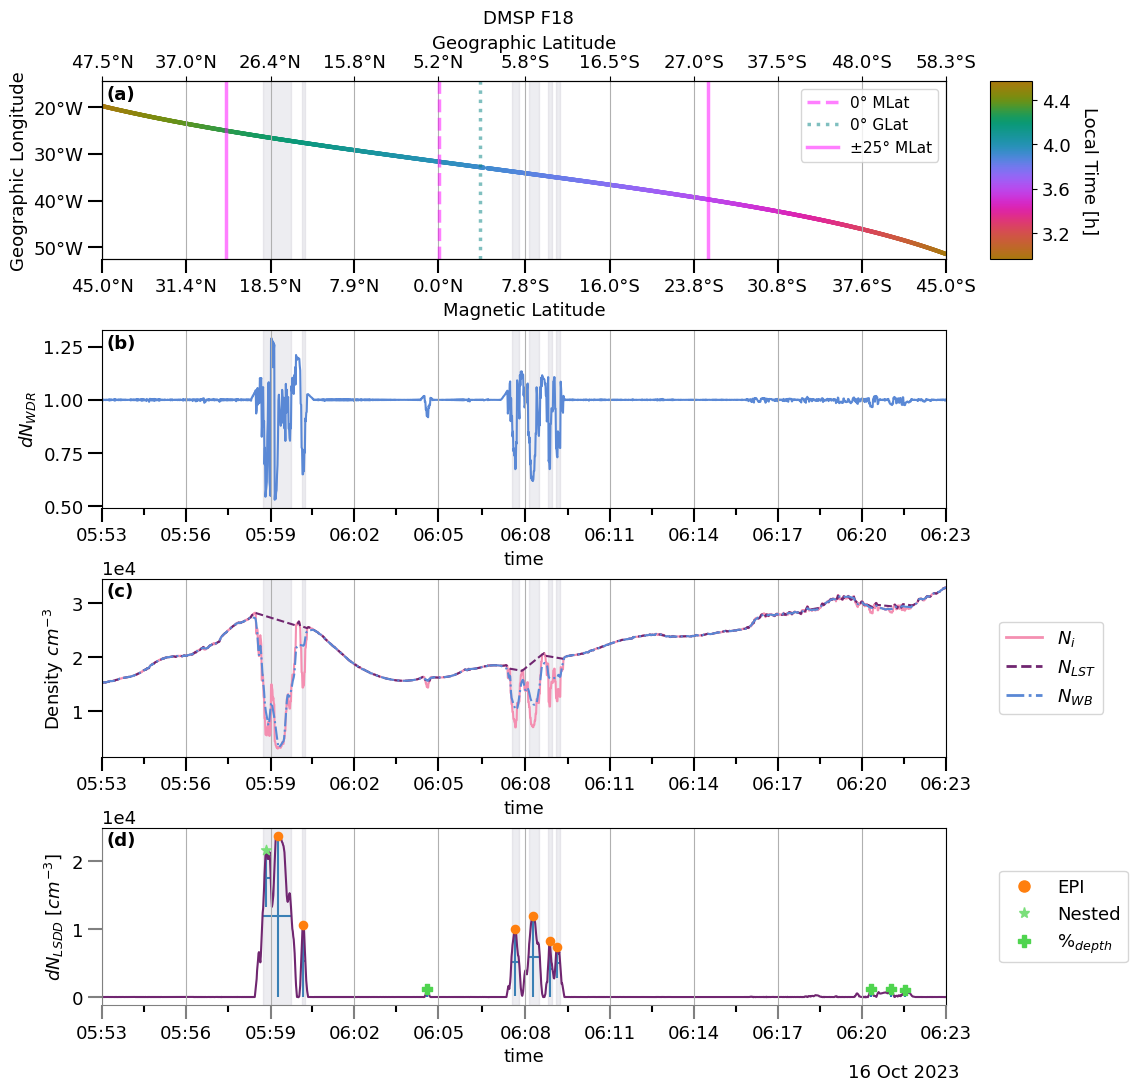

In [10]:
# Create Figure
fig, ax_list = dplot.detection_plot(
    data_df_lat, 'time', barrel_df, cand_df, peaks, properties, flag_mark=True,
    xtype='datetime', leg_ax=None, xlim=None, xlab=None, n_type='i', n_unit='$cm^{-3}$',
    lon_lim=[-52.5, -14.5], time_str='time', lon_str='lon', lt_hr_str='lt_hr',
    mlat_str='mlat', lt_str='lt', lat_str='lat', shade_epi=True,
    shade_col="#A7A6BA", shade_alpha=0.2, sat_name='DMSP F18', fs=13)

plotL1.add_alphalabels(ax_list, inout='in', color='black', yperc=10, xperc=0.5,
                        fs=13, bold=True, start_num=0)

fig_dir = '/Users/alanahco/Library/Mobile Documents/com~apple~CloudDocs/Documents/Grad School/EPB/Python Code/pySpyEPI/docs/pySpyEPI_figs/'
fig_save = fig_dir + 'DMSP_test.png'
fig.savefig(fig_save, bbox_inches='tight', dpi=300)